# Project 01 — Complete DistilBART GPU Fine-Tuning and Evaluation Pipeline

This notebook turns Project 01 into a reproducible model-development study. It creates actual baseline, pretrained, fine-tuned, optional LSTM, ROUGE, BERTScore, latency, compression, numeric-risk, repetition, chart, and error-analysis artifacts. No metric is published until real inference finishes.

## Run order
1. Validate dependencies and RTX CUDA.
2. Select a scale profile.
3. Load deterministic CNN/DailyMail 3.0.0 subsets.
4. Generate Lead-3 and TextRank baselines.
5. Evaluate pretrained DistilBART.
6. Fine-tune DistilBART with mixed precision and gradient checkpointing.
7. Evaluate the fine-tuned checkpoint on the same test subset.
8. Compute BERTScore once for all methods.
9. Optionally import real LSTM predictions.
10. Generate JSON, CSV, Markdown, and PNG evidence and validate it.

In [1]:
from pathlib import Path
import sys
START = Path.cwd().resolve()
PROJECT_NAME = "01-abstractive-text-summarization-transformer"
PROJECT_ROOT = None
for candidate in [START, *START.parents]:
    if (candidate/"src").is_dir() and (candidate/"configs").is_dir():
        PROJECT_ROOT = candidate; break
    if (candidate/PROJECT_NAME/"src").is_dir():
        PROJECT_ROOT = candidate/PROJECT_NAME; break
if PROJECT_ROOT is None: raise RuntimeError("Project root not found")
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer


In [2]:
import importlib.util
required = ["torch","transformers","datasets","rouge_score","bert_score","accelerate","yaml","pandas","matplotlib"]
missing = [x for x in required if importlib.util.find_spec(x) is None]
if missing: raise RuntimeError("Missing modules: " + ", ".join(missing) + "\nRun: python -m pip install -r requirements-training.txt")
print("Dependencies passed")

Dependencies passed


In [3]:
import gc, json, os, random
from datetime import datetime, timezone
import numpy as np, pandas as pd, torch, yaml
from IPython.display import display
CONFIG = yaml.safe_load((PROJECT_ROOT/"configs/portfolio_experiment.yaml").read_text(encoding="utf-8"))
PROFILE = CONFIG["experiment"]["profile"]
P = CONFIG["profiles"][PROFILE]
SEED = int(CONFIG["experiment"]["seed"])
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_DIR = PROJECT_ROOT/"outputs/benchmark/runs"/RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print(PROFILE, P, RUN_ID)

portfolio {'train_samples': 5000, 'validation_samples': 500, 'test_samples': 500, 'epochs': 2} 20260729T172001Z


## 1. RTX hardware audit

In [4]:
from src.benchmark_utils import hardware_report, save_json
hardware = hardware_report(); display(hardware); save_json(RUN_DIR/"hardware_report.json", hardware)
if CONFIG["experiment"].get("require_cuda", True) and not hardware.get("cuda_available"):
    raise RuntimeError("CUDA is unavailable to PyTorch")
USE_BF16 = bool(hardware.get("bf16_supported", False)); USE_FP16 = bool(hardware.get("cuda_available") and not USE_BF16)
print("Precision:", "BF16" if USE_BF16 else "FP16" if USE_FP16 else "FP32")

{'python': '3.13.14',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 198 Stepping 2, GenuineIntel',
 'cuda_available': True,
 'torch_version': '2.12.1+cu132',
 'cuda_runtime': '13.2',
 'cudnn_version': 92000,
 'gpu_count': 1,
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'gpu_memory_gb': 31.84,
 'bf16_supported': True}

Precision: BF16


## 2. Load deterministic CNN/DailyMail subsets

In [5]:
from datasets import DatasetDict, load_dataset
DATASET_ID = CONFIG["experiment"]["dataset_id"]; DATASET_CONFIG = CONFIG["experiment"]["dataset_config"]
raw = load_dataset(DATASET_ID, DATASET_CONFIG)
def normalize(split, n):
    ds = raw[split].shuffle(seed=SEED).select(range(int(n))).rename_column("highlights","reference_summary")
    remove = [c for c in ds.column_names if c not in {"id","article","reference_summary"}]
    return ds.remove_columns(remove) if remove else ds
D = DatasetDict({"train":normalize("train",P["train_samples"]),"validation":normalize("validation",P["validation_samples"]),"test":normalize("test",P["test_samples"])})
D

README.md: 0.00B [00:00, ?B/s]

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atripathi\.cache\huggingface\hub\datasets--abisee--cnn_dailymail. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
X

train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'reference_summary', 'id'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['article', 'reference_summary', 'id'],
        num_rows: 500
    })
    test: Dataset({
        features: ['article', 'reference_summary', 'id'],
        num_rows: 500
    })
})

## 3. Dataset audit and local LSTM input export

In [6]:
from src.text_preprocessing import word_count
stats={"status":"completed","dataset_id":DATASET_ID,"dataset_config":DATASET_CONFIG,"seed":SEED,"profile":PROFILE,"splits":{}}
for split, ds in D.items():
    f=ds.to_pandas(); a=f.article.map(word_count); s=f.reference_summary.map(word_count)
    stats["splits"][split]={"samples":len(f),"average_article_words":float(a.mean()),"median_article_words":float(a.median()),"maximum_article_words":int(a.max()),"average_reference_words":float(s.mean()),"median_reference_words":float(s.median()),"maximum_reference_words":int(s.max())}
save_json(RUN_DIR/"dataset_statistics.json",stats); display(pd.DataFrame(stats["splits"]).T)
test=D["test"].to_pandas(); cache=PROJECT_ROOT/"data/benchmark_cache"; cache.mkdir(parents=True,exist_ok=True)
test[["id","article"]].to_csv(cache/"lstm_benchmark_input.csv",index=False)

,samples,average_article_words,median_article_words,maximum_article_words,average_reference_words,median_reference_words,maximum_reference_words
train,5000.0,680.9054,623.0,1867.0,47.8386,45.0,326.0
validation,500.0,652.8000,568.5,1694.0,53.0060,49.0,123.0
test,500.0,681.5540,609.0,1811.0,52.7120,48.0,154.0


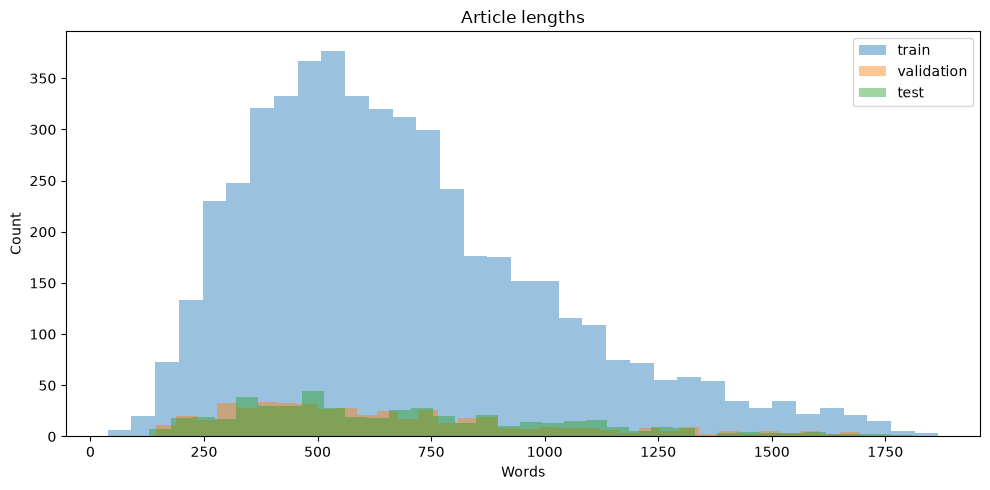

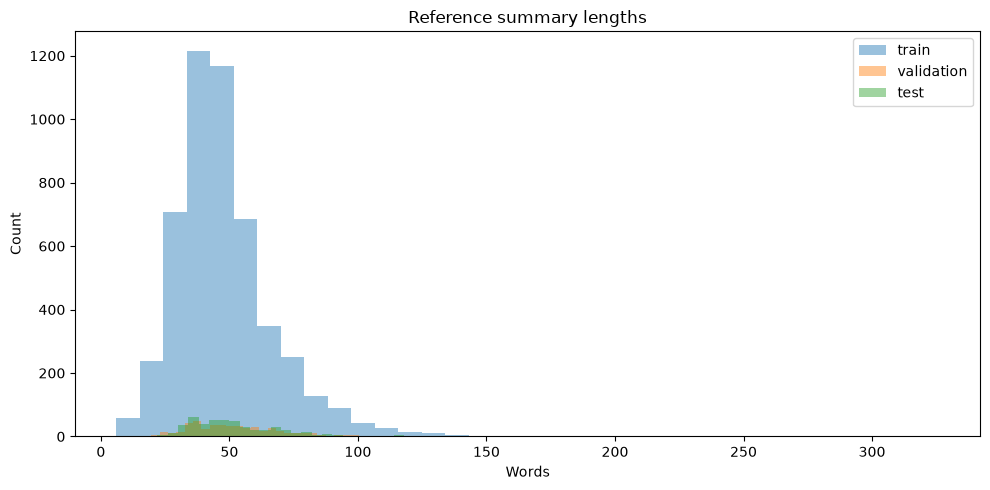

In [7]:
import matplotlib.pyplot as plt
for title, column, filename in [("Article lengths","article","benchmark_article_length_distribution.png"),("Reference summary lengths","reference_summary","benchmark_summary_length_distribution.png")]:
    plt.figure(figsize=(10,5))
    for split, ds in D.items(): plt.hist(ds.to_pandas()[column].map(word_count),bins=35,alpha=.45,label=split)
    plt.title(title); plt.xlabel("Words"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images"/filename,dpi=180,bbox_inches="tight"); plt.show()

## 4. Lead-3 and TextRank baselines

In [8]:
from src.benchmark_utils import run_baseline
articles=test.article.astype(str).tolist(); references=test.reference_summary.astype(str).tolist()
test["lead3_summary"],test["lead3_inference_seconds"]=run_baseline(articles,"lead3")
test["textrank_summary"],test["textrank_inference_seconds"]=run_baseline(articles,"textrank")
print(len(test),"baseline predictions completed")

500 baseline predictions completed


## 5. Pretrained DistilBART inference

In [9]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.benchmark_utils import GenerationConfig, generate_batched, release_memory
BASE_MODEL=CONFIG["model"]["base_model"]
G=GenerationConfig(max_source_tokens=int(CONFIG["model"]["max_source_tokens"]),min_new_tokens=int(CONFIG["inference"]["min_new_tokens"]),max_new_tokens=int(CONFIG["inference"]["max_new_tokens"]),num_beams=int(CONFIG["inference"]["num_beams"]),length_penalty=float(CONFIG["inference"]["length_penalty"]),no_repeat_ngram_size=int(CONFIG["inference"]["no_repeat_ngram_size"]),batch_size=int(CONFIG["inference"]["batch_size"]))
tok=AutoTokenizer.from_pretrained(BASE_MODEL,use_fast=True); model=AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
out=generate_batched(model,tok,articles,G); test["pretrained_summary"]=out["summaries"]; test["pretrained_inference_seconds"]=out["latencies"]
print("Peak MB",out["peak_gpu_memory_mb"]); del model,tok; release_memory()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atripathi\.cache\huggingface\hub\models--sshleifer--distilbart-cnn-12-6. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(mes

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Peak MB 1493.16064453125


## 6. Fine-tune DistilBART

In [10]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments
from src.model_evaluation import compute_rouge
MODEL_DIR=PROJECT_ROOT/CONFIG["model"]["output_directory"]
tokenizer=AutoTokenizer.from_pretrained(BASE_MODEL,use_fast=True); model=AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
if CONFIG["training"]["gradient_checkpointing"]: model.gradient_checkpointing_enable(); model.config.use_cache=False
max_src=int(CONFIG["model"]["max_source_tokens"]); max_tgt=int(CONFIG["model"]["max_target_tokens"])
def tokenize(batch):
    x=tokenizer(batch["article"],max_length=max_src,truncation=True)
    x["labels"]=tokenizer(text_target=batch["reference_summary"],max_length=max_tgt,truncation=True)["input_ids"]
    return x
train_tok=D["train"].map(tokenize,batched=True,remove_columns=D["train"].column_names)
val_tok=D["validation"].map(tokenize,batched=True,remove_columns=D["validation"].column_names)
def trainer_metrics(pred):
    predictions,labels=pred
    if isinstance(predictions,tuple): predictions=predictions[0]
    decoded=tokenizer.batch_decode(predictions,skip_special_tokens=True)
    labels=np.where(labels!=-100,labels,tokenizer.pad_token_id)
    refs=tokenizer.batch_decode(labels,skip_special_tokens=True)
    return compute_rouge(decoded,refs)
args=Seq2SeqTrainingArguments(output_dir=str(MODEL_DIR),learning_rate=float(CONFIG["training"]["learning_rate"]),per_device_train_batch_size=int(CONFIG["training"]["train_batch_size"]),per_device_eval_batch_size=int(CONFIG["training"]["evaluation_batch_size"]),gradient_accumulation_steps=int(CONFIG["training"]["gradient_accumulation_steps"]),num_train_epochs=int(P["epochs"]),weight_decay=float(CONFIG["training"]["weight_decay"]),warmup_ratio=float(CONFIG["training"]["warmup_ratio"]),eval_strategy="epoch",save_strategy="epoch",logging_strategy="steps",logging_steps=int(CONFIG["training"]["logging_steps"]),predict_with_generate=True,generation_max_length=max_tgt,generation_num_beams=int(CONFIG["training"]["generation_beams"]),load_best_model_at_end=True,metric_for_best_model="rougeL",greater_is_better=True,save_total_limit=int(CONFIG["training"]["save_total_limit"]),report_to="none",fp16=USE_FP16,bf16=USE_BF16,gradient_checkpointing=bool(CONFIG["training"]["gradient_checkpointing"]),eval_accumulation_steps=1,dataloader_num_workers=0,optim="adamw_torch",seed=SEED,data_seed=SEED)
trainer=Seq2SeqTrainer(model=model,args=args,train_dataset=train_tok,eval_dataset=val_tok,processing_class=tokenizer,data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer,model=model),compute_metrics=trainer_metrics)
train_result=trainer.train(); eval_result=trainer.evaluate(); model.config.use_cache=True; trainer.save_model(MODEL_DIR); tokenizer.save_pretrained(MODEL_DIR)
training_summary={"status":"completed","train_metrics":train_result.metrics,"evaluation_metrics":eval_result,"best_model_checkpoint":trainer.state.best_model_checkpoint,"best_metric":trainer.state.best_metric,"global_step":trainer.state.global_step,"log_history":trainer.state.log_history}
save_json(MODEL_DIR/"training_summary.json",training_summary)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,1.528100,1.542324,0.444994,0.217583,0.315544
2,1.260700,1.573217,0.446943,0.216284,0.313058


C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer\.venv\Lib\site-packages\transformers\modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


WindowsPath('C:/Users/atripathi/OneDrive - Veralto/Desktop/AI Codes/GIT Projects/transformer-projects/01-abstractive-text-summarization-transformer/models/distilbart_cnn_finetuned/training_summary.json')

## 7. Training curves

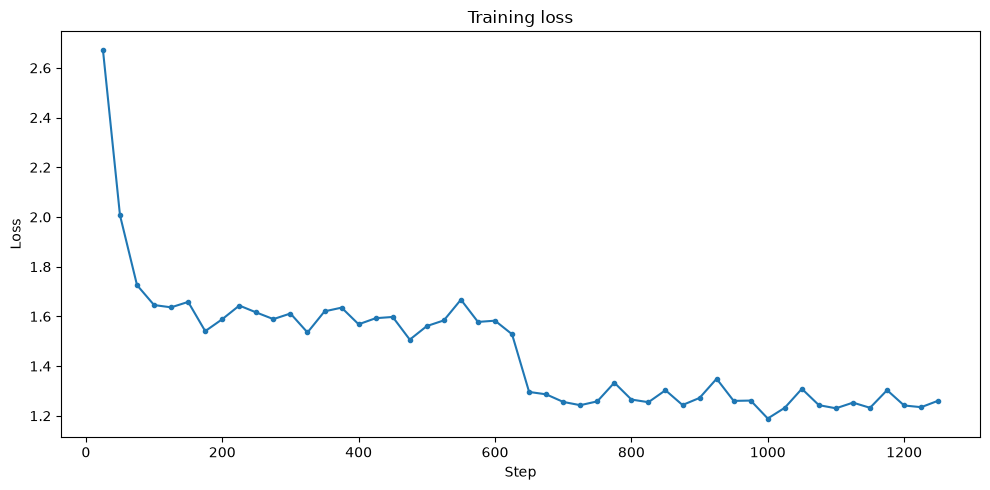

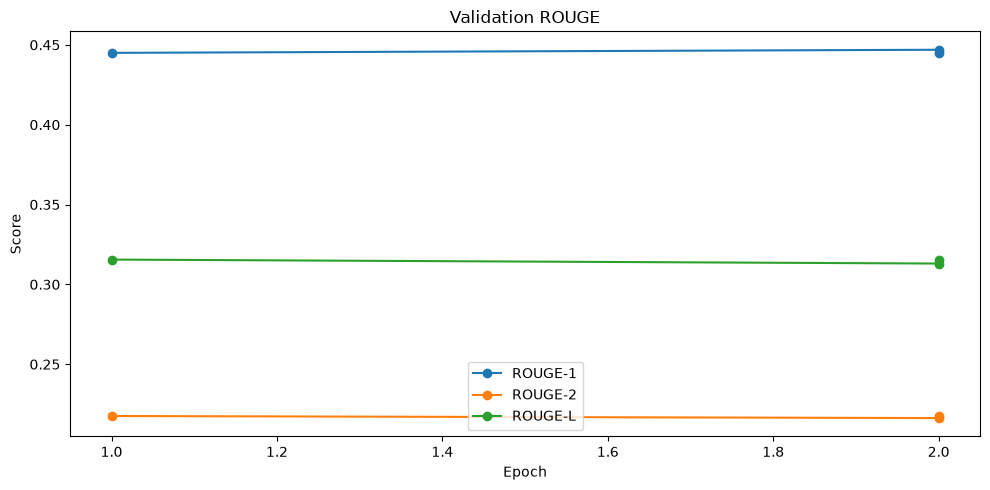

In [11]:
logs=pd.DataFrame(training_summary["log_history"]); logs.to_csv(RUN_DIR/"training_log_history.csv",index=False)
if "loss" in logs:
    x=logs.dropna(subset=["loss"]); plt.figure(figsize=(10,5)); plt.plot(x.step,x.loss,marker="o",markersize=3); plt.title("Training loss"); plt.xlabel("Step"); plt.ylabel("Loss"); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images/training_curve.png",dpi=180,bbox_inches="tight"); plt.show()
if "eval_rougeL" in logs:
    x=logs.dropna(subset=["eval_rougeL"]); plt.figure(figsize=(10,5)); plt.plot(x.epoch,x.eval_rouge1,marker="o",label="ROUGE-1"); plt.plot(x.epoch,x.eval_rouge2,marker="o",label="ROUGE-2"); plt.plot(x.epoch,x.eval_rougeL,marker="o",label="ROUGE-L"); plt.legend(); plt.title("Validation ROUGE"); plt.xlabel("Epoch"); plt.ylabel("Score"); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images/validation_rouge_curve.png",dpi=180,bbox_inches="tight"); plt.show()

## 8. Fine-tuned inference

In [12]:
fine_out=generate_batched(model,tokenizer,articles,G); test["fine_tuned_summary"]=fine_out["summaries"]; test["fine_tuned_inference_seconds"]=fine_out["latencies"]
print("Peak MB",fine_out["peak_gpu_memory_mb"]); del model,tokenizer,trainer; release_memory()

Peak MB 3855.353515625


## 9. BERTScore for all approaches

In [13]:
RUN_BERTSCORE=bool(CONFIG["metrics"]["compute_bertscore"])
METHODS={"Lead-3":("lead3_summary","lead3"),"TextRank":("textrank_summary","textrank"),"Pretrained DistilBART":("pretrained_summary","pretrained"),"Fine-tuned DistilBART":("fine_tuned_summary","fine_tuned")}
if RUN_BERTSCORE:
    from bert_score import BERTScorer
    scorer=BERTScorer(lang="en",model_type=CONFIG["metrics"]["bertscore_model"],rescale_with_baseline=True,device="cuda" if torch.cuda.is_available() else "cpu")
    for _,(col,prefix) in METHODS.items():
        Pm,Rm,Fm=scorer.score(test[col].astype(str).tolist(),references,batch_size=int(CONFIG["metrics"]["bertscore_batch_size"]))
        test[f"{prefix}_bertscore_precision"]=Pm.cpu().numpy(); test[f"{prefix}_bertscore_recall"]=Rm.cpu().numpy(); test[f"{prefix}_bertscore_f1"]=Fm.cpu().numpy()
    del scorer; release_memory()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atripathi\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 10. Optional real LSTM comparison

In [14]:
lstm_available=False; lstm_path=PROJECT_ROOT/"data/lstm_predictions.csv"
if lstm_path.exists():
    lf=pd.read_csv(lstm_path)
    if {"id","lstm_summary"}.issubset(lf.columns) and not lf.empty:
        lf=lf.dropna(subset=["id","lstm_summary"]); coverage=test[["id"]].merge(lf,on="id",how="left").lstm_summary.notna().mean(); print("Coverage",coverage)
        if coverage>=.95: test=test.merge(lf,on="id",how="left"); lstm_available=True
if lstm_available and RUN_BERTSCORE:
    scorer=BERTScorer(lang="en",model_type=CONFIG["metrics"]["bertscore_model"],rescale_with_baseline=True,device="cuda" if torch.cuda.is_available() else "cpu")
    Pm,Rm,Fm=scorer.score(test.lstm_summary.astype(str).tolist(),references,batch_size=int(CONFIG["metrics"]["bertscore_batch_size"]))
    test["lstm_bertscore_precision"]=Pm.cpu().numpy(); test["lstm_bertscore_recall"]=Rm.cpu().numpy(); test["lstm_bertscore_f1"]=Fm.cpu().numpy(); del scorer; release_memory()

## 11. Aggregate metrics

In [15]:
from src.benchmark_utils import evaluate_method, comparison_frame, build_error_analysis
specs={"Lead-3":("lead3_summary","lead3_inference_seconds","lead3"),"TextRank":("textrank_summary","textrank_inference_seconds","textrank"),"Pretrained DistilBART":("pretrained_summary","pretrained_inference_seconds","pretrained"),"Fine-tuned DistilBART":("fine_tuned_summary","fine_tuned_inference_seconds","fine_tuned")}
if lstm_available: specs["LSTM Seq2Seq with Attention"]=("lstm_summary","lstm_inference_seconds" if "lstm_inference_seconds" in test else None,"lstm")
metrics_by_method={}; details={}
for name,(pred,lat,prefix) in specs.items(): metrics_by_method[name],details[name]=evaluate_method(test,name,pred,lat,prefix if RUN_BERTSCORE else None)
comparison=comparison_frame(metrics_by_method); display(comparison.round(4))
error_analysis=build_error_analysis(details["Fine-tuned DistilBART"]); display(error_analysis.quality_band.value_counts())

,model,samples,rouge1,rouge2,rougeL,bertscore_precision,bertscore_recall,bertscore_f1,average_inference_seconds,p95_inference_seconds,average_compression_ratio,average_reference_number_recall,average_hallucinated_number_count
0,Lead-3,500,0.4008,0.1718,0.2468,0.2101,0.2419,0.2263,0.0002,0.0004,0.1468,0.6422,0.000
1,TextRank,500,0.3489,0.1363,0.2289,0.1663,0.2030,0.1850,0.0014,0.0024,0.1494,0.5449,0.000
2,Pretrained DistilBART,500,0.4469,0.2155,0.3082,0.2896,0.3351,0.3127,0.3674,0.4861,0.1200,0.7129,0.024
3,Fine-tuned DistilBART,500,0.4386,0.2062,0.3003,0.3363,0.3462,0.3416,0.3280,0.4422,0.1015,0.6775,0.024


quality_band
mixed     289
weak      132
strong     79
Name: count, dtype: int64

## 12. Recruiter-facing charts

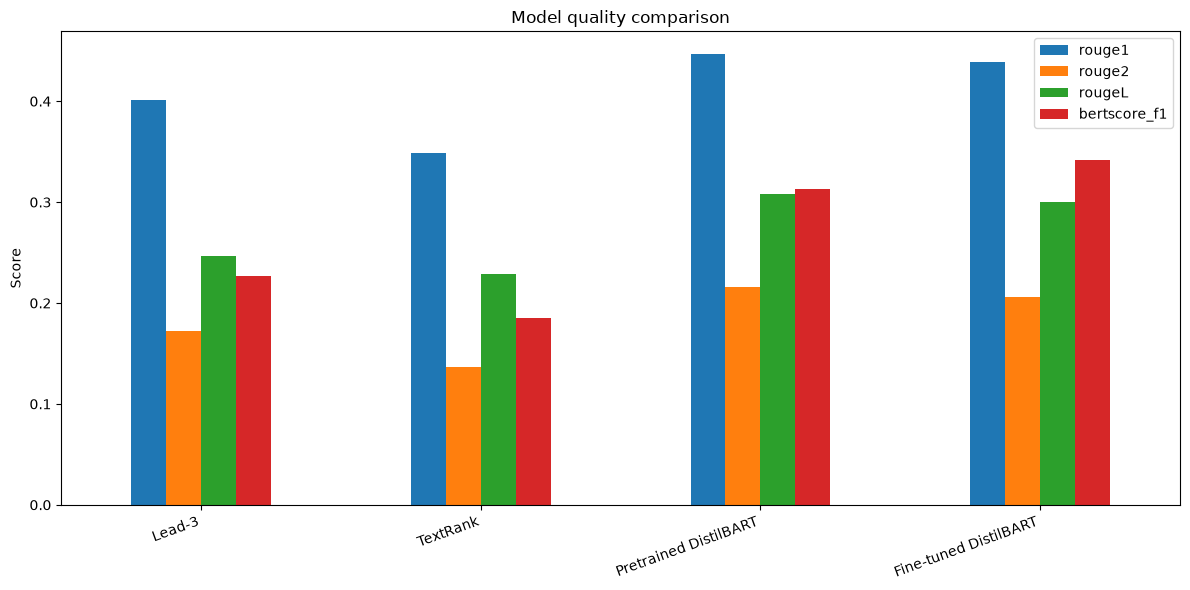

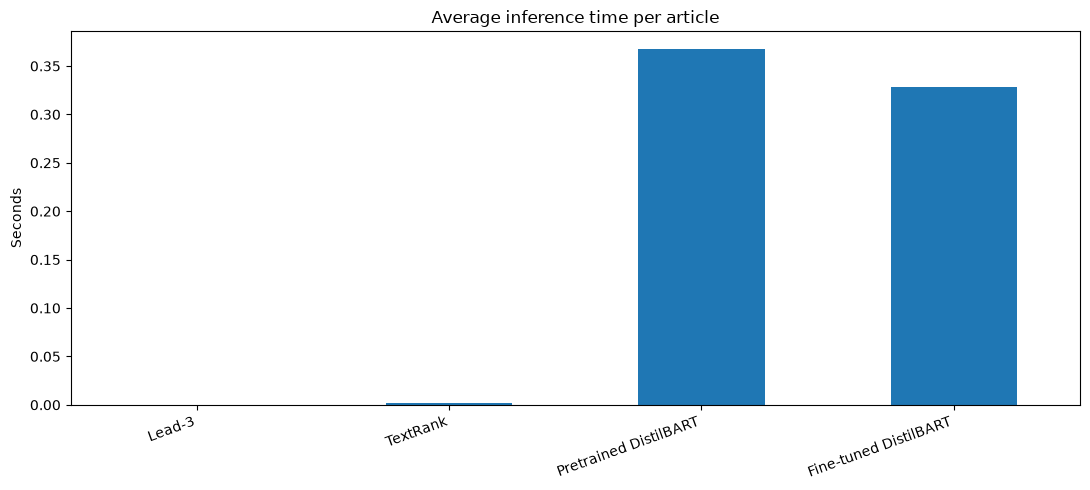

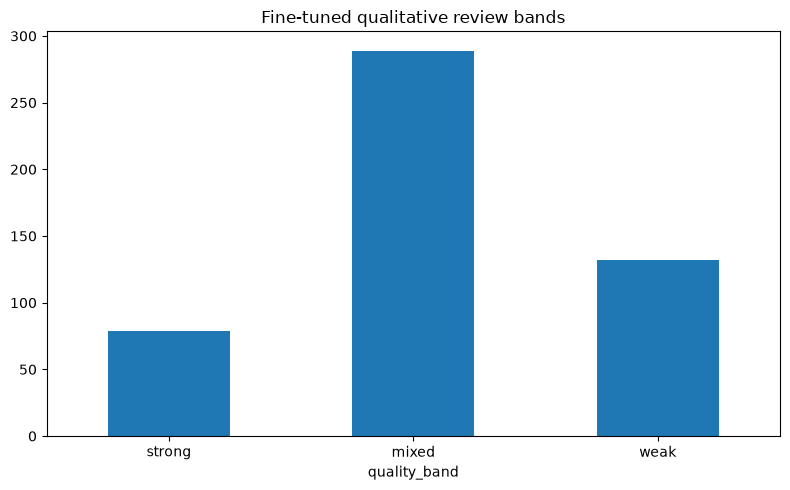

In [16]:
plot=comparison.set_index("model")
plt.figure(figsize=(12,6)); plot[["rouge1","rouge2","rougeL","bertscore_f1"]].plot(kind="bar",ax=plt.gca()); plt.title("Model quality comparison"); plt.xlabel(""); plt.ylabel("Score"); plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images/model_performance_comparison.png",dpi=200,bbox_inches="tight"); plt.show()
lat=comparison.dropna(subset=["average_inference_seconds"]).set_index("model"); plt.figure(figsize=(11,5)); lat.average_inference_seconds.plot(kind="bar"); plt.title("Average inference time per article"); plt.xlabel(""); plt.ylabel("Seconds"); plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images/latency_comparison.png",dpi=200,bbox_inches="tight"); plt.show()
plt.figure(figsize=(8,5)); error_analysis.quality_band.value_counts().reindex(["strong","mixed","weak"],fill_value=0).plot(kind="bar"); plt.title("Fine-tuned qualitative review bands"); plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(PROJECT_ROOT/"images/error_analysis_summary.png",dpi=200,bbox_inches="tight"); plt.show()

## 13. Publish actual outputs

In [17]:
from src.benchmark_utils import publish_outputs
manifest={"status":"completed","run_id":RUN_ID,"completed_at":datetime.now(timezone.utc).isoformat(),"profile":PROFILE,"seed":SEED,"dataset":{"id":DATASET_ID,"config":DATASET_CONFIG,"train_samples":len(D["train"]),"validation_samples":len(D["validation"]),"test_samples":len(D["test"])},"models":{"pretrained":BASE_MODEL,"fine_tuned":str(MODEL_DIR),"hugging_face_model_repo":CONFIG["publishing"]["hugging_face_model_repo"],"static_browser_model":"Xenova/distilbart-cnn-12-6"},"generation":G.__dict__,"hardware":hardware,"lstm_comparison_included":lstm_available,"notes":["Subset-specific benchmark, not a full-dataset leaderboard claim.","Static Space uses the base browser ONNX model unless separately converted."]}
publish_outputs(PROJECT_ROOT,RUN_DIR,manifest,stats,training_summary,metrics_by_method,comparison,test,error_analysis)
print("Published outputs to",PROJECT_ROOT/"outputs/benchmark/latest")

Published outputs to C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\01-abstractive-text-summarization-transformer\outputs\benchmark\latest


## 14. Create fine-tuned model card and optional Model Hub upload

In [18]:
fine=comparison[comparison.model=="Fine-tuned DistilBART"].iloc[0]
card=f"""---
language: en
license: apache-2.0
library_name: transformers
pipeline_tag: summarization
base_model: {BASE_MODEL}
datasets:
- {DATASET_ID}
metrics:
- rouge
- bertscore
---
# Project 01 Fine-tuned DistilBART

Fine-tuned by Anmol Tripathi on {len(D['train'])} CNN/DailyMail examples and evaluated on {len(D['test'])} held-out examples.

| Metric | Value |
|---|---:|
| ROUGE-1 | {fine.rouge1:.4f} |
| ROUGE-2 | {fine.rouge2:.4f} |
| ROUGE-L | {fine.rougeL:.4f} |
| BERTScore F1 | {fine.bertscore_f1:.4f} |

These are subset results, not full-dataset leaderboard claims. Human review is required because summaries may omit or hallucinate facts.
"""
(MODEL_DIR/"README.md").write_text(card,encoding="utf-8")
if CONFIG["publishing"]["push_model_to_hub"]:
    from getpass import getpass
    from huggingface_hub import HfApi
    repo_id=CONFIG["publishing"]["hugging_face_model_repo"]; token=os.environ.get("HF_TOKEN") or getpass("HF write token: "); api=HfApi(token=token); api.create_repo(repo_id=repo_id,repo_type="model",exist_ok=True); api.upload_folder(repo_id=repo_id,repo_type="model",folder_path=MODEL_DIR,commit_message=f"Project 01 benchmark {RUN_ID}")

## 15. Final validation

In [19]:
from src.benchmark_utils import validate_outputs
minimum=40 if PROFILE=="smoke" else 150 if PROFILE=="balanced" else 200
result=validate_outputs(PROJECT_ROOT,minimum); display(result)
assert len(test)==int(P["test_samples"])
print("PROJECT 01 GPU BENCHMARK COMPLETED SUCCESSFULLY")

{'status': 'valid',
 'test_samples': 500,
 'methods': ['Fine-tuned DistilBART',
  'Lead-3',
  'Pretrained DistilBART',
  'TextRank'],
 'files_validated': 7}

PROJECT 01 GPU BENCHMARK COMPLETED SUCCESSFULLY


## Commit checklist
Review `outputs/benchmark/latest/PORTFOLIO_RESULTS.md`, `model_comparison.csv`, `error_analysis_examples.md`, generated charts, and weak summaries. Then run `python scripts\validate_portfolio_outputs.py --minimum-samples 200` and `python -m pytest -q` before pushing.